In [1]:
# Cell 1 - imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

%matplotlib inline
sns.set(style="whitegrid")


In [2]:
# Cell 2 - load csv
df = pd.read_csv("iris.csv")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
display(df.head())

# auto-detect target column (assume last column if not 'species')
if 'species' in df.columns:
    target_col = 'species'
else:
    target_col = df.columns[-1]

print("Using target column:", target_col)

# prepare X, y
X = df.drop(columns=[target_col])
y = df[target_col]

# if target is text, encode to numeric for some metrics (sklearn can accept strings, but encoding is safer)
if y.dtype == 'object' or y.dtype.name == 'category':
    le = LabelEncoder()
    y = le.fit_transform(y)
    print("Encoded target classes:", le.classes_)
else:
    # keep numeric labels
    le = None


Shape: (150, 6)
Columns: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Using target column: Species
Encoded target classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000      3.000000       4.350000      1.300000
75%    112.750000       6.400000      3.300000       5.100000      1.800000
max    150.000000       7.900000      4.400000       6.900000      2.500000
Example class distribution (counts):
0    50
1    50
2    50
Name: count, dtype: int64


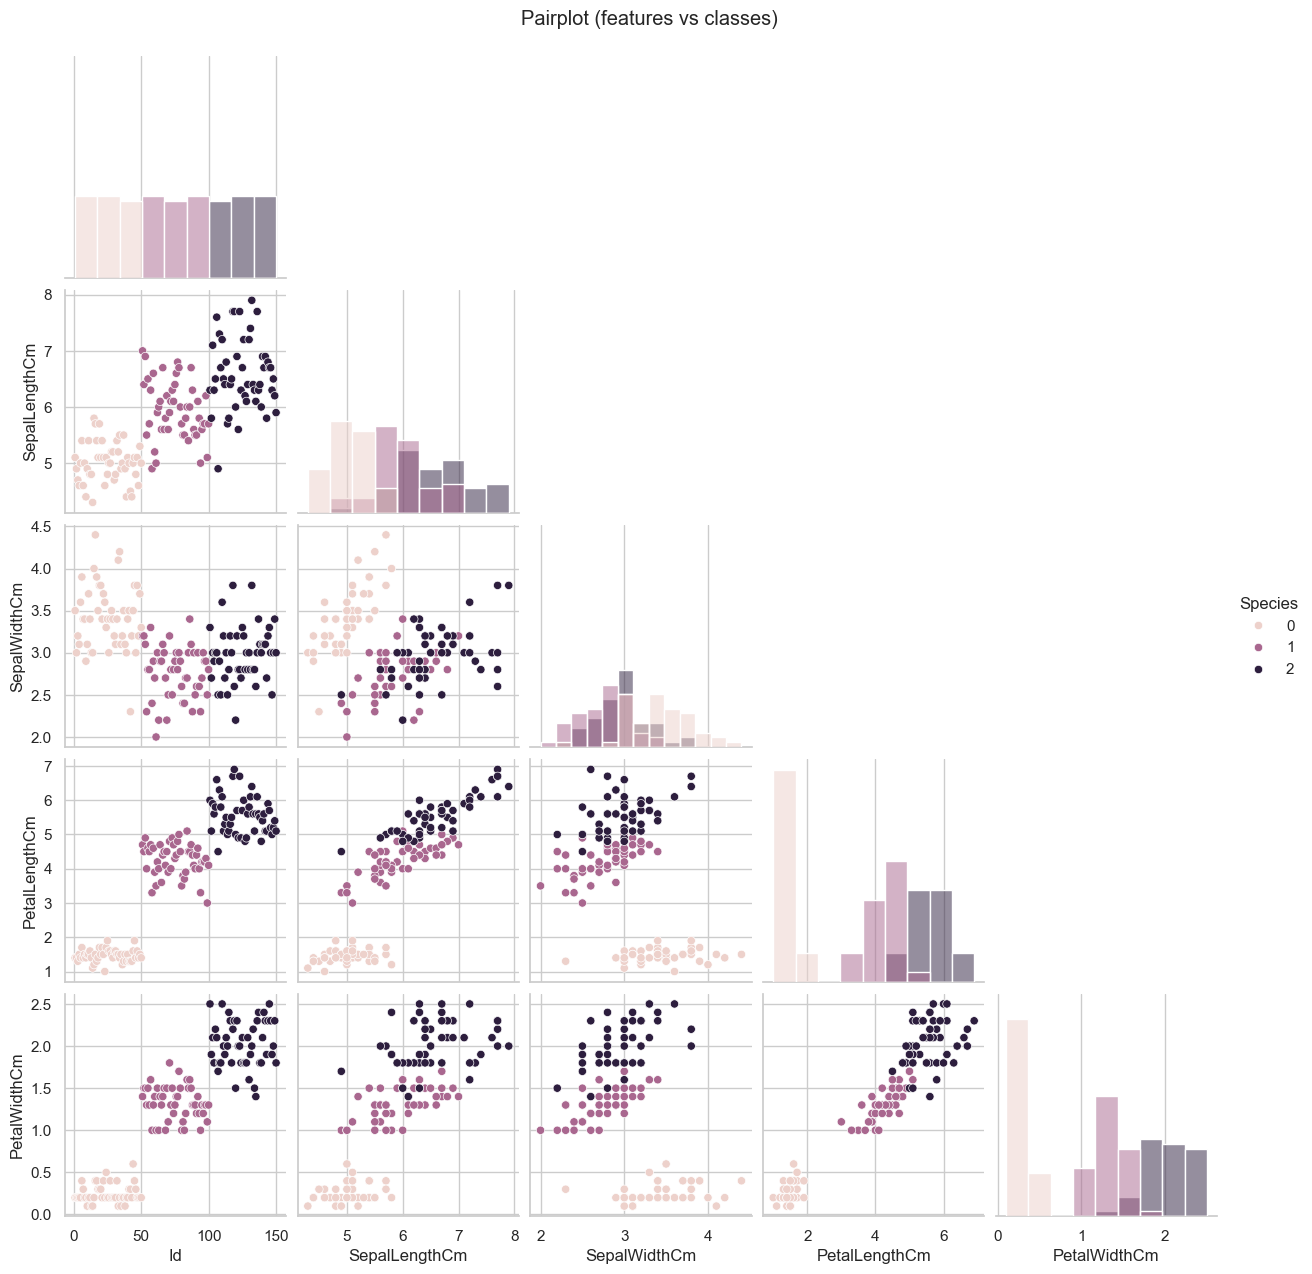

In [3]:
# Cell 3 - EDA
print(X.describe())
unique_counts = pd.Series(y).shape[0]
print("Example class distribution (counts):")
print(pd.Series(y).value_counts())

# Pairplot (optional; will display if dataset small)
try:
    df_plot = X.copy()
    df_plot[target_col] = pd.Series(y)
    sns.pairplot(df_plot, hue=target_col, diag_kind='hist', corner=True)
    plt.suptitle("Pairplot (features vs classes)", y=1.02)
except Exception as e:
    print("Pairplot skipped:", e)


In [4]:
# Cell 4 - split & scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (120, 5) Test shape: (30, 5)


Accuracy (k=5): 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



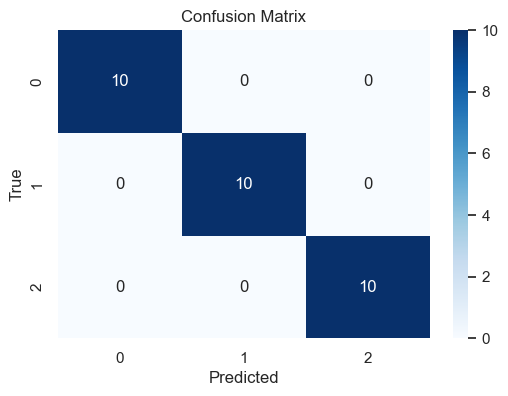

In [5]:
# Cell 5 - baseline
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

print("Accuracy (k=5):", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix")
plt.show()


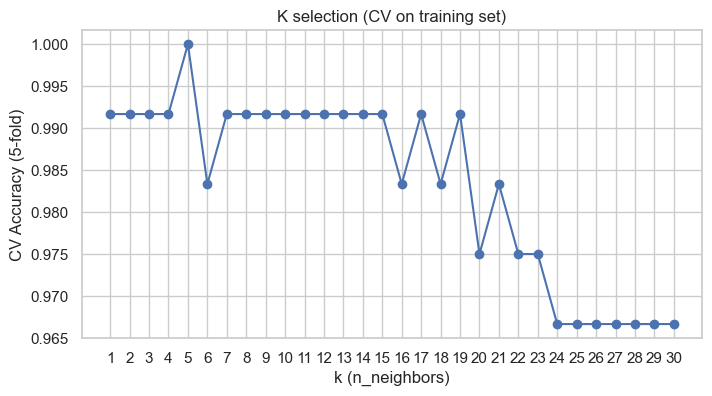

Best k according to CV: 5 with CV accuracy: 1.0


In [6]:
# Cell 6 - cross-validation to choose k
k_list = list(range(1,31))
cv_scores = []

for k in k_list:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipeline, X_train, y_train, cv=5)
    cv_scores.append(scores.mean())

plt.figure(figsize=(8,4))
plt.plot(k_list, cv_scores, marker='o')
plt.xlabel('k (n_neighbors)')
plt.ylabel('CV Accuracy (5-fold)')
plt.title('K selection (CV on training set)')
plt.xticks(k_list)
plt.grid(True)
plt.show()

best_k = k_list[int(np.argmax(cv_scores))]
print("Best k according to CV:", best_k, "with CV accuracy:", max(cv_scores))


Final Test Accuracy: 1.0

Final Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



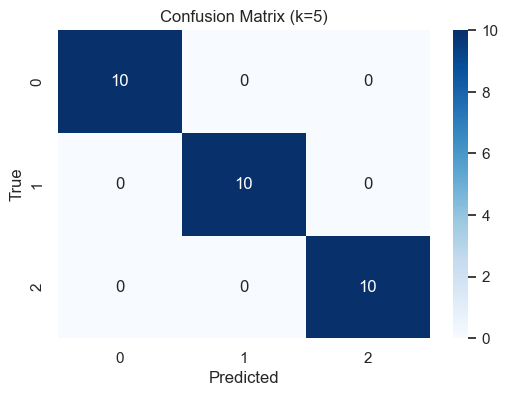

In [7]:
# Cell 7 - final model
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k))
])

final_pipeline.fit(X_train, y_train)
y_final_pred = final_pipeline.predict(X_test)

print("Final Test Accuracy:", accuracy_score(y_test, y_final_pred))
print("\nFinal Classification Report:\n", classification_report(y_test, y_final_pred))

cm = confusion_matrix(y_test, y_final_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f'Confusion Matrix (k={best_k})')
plt.show()


Plotting features: ['Id', 'SepalLengthCm']


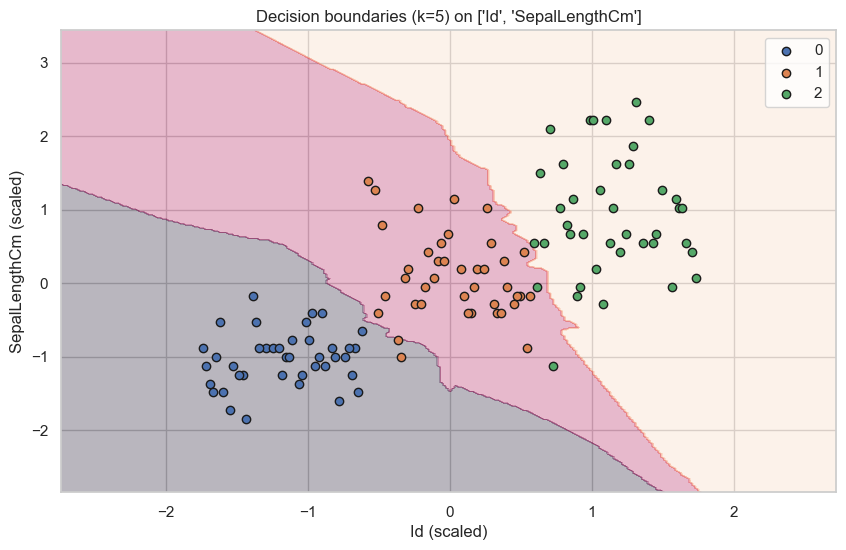

In [8]:
# Optional - replace feature names below as needed
feat_cols = list(X.columns[:2])   # first two features
print("Plotting features:", feat_cols)

X2 = X[feat_cols].values
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42, stratify=y)

scaler2 = StandardScaler()
X2_train_s = scaler2.fit_transform(X2_train)
X2_test_s = scaler2.transform(X2_test)

knn2 = KNeighborsClassifier(n_neighbors=best_k)
knn2.fit(X2_train_s, y2_train)

# mesh
x_min, x_max = X2_train_s[:,0].min() - 1, X2_train_s[:,0].max() + 1
y_min, y_max = X2_train_s[:,1].min() - 1, X2_train_s[:,1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = knn2.predict(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,6))
plt.contourf(xx, yy, Z, alpha=0.3)
for cls in np.unique(y2_train):
    plt.scatter(X2_train_s[y2_train==cls,0], X2_train_s[y2_train==cls,1], label=str(cls), edgecolor='k')
plt.legend()
plt.xlabel(feat_cols[0] + " (scaled)")
plt.ylabel(feat_cols[1] + " (scaled)")
plt.title(f"Decision boundaries (k={best_k}) on {feat_cols}")
plt.show()


In [9]:
# Cell 9 - save
joblib.dump(final_pipeline, "knn_pipeline.joblib")
print("Saved final pipeline to knn_pipeline.joblib")


Saved final pipeline to knn_pipeline.joblib
